# 01.4 — HVG Flavor Comparison (Training-Only)

This notebook investigates which `sc.pp.highly_variable_genes` flavor produces a top-1000 list that better matches the biology we care about (broadly expressed lineage markers, not just sparse-bright outliers). It is motivated by the observation in `01.1` that `flavor="seurat"` excludes `PTPRC` (and other broadly expressed leukocyte markers) from the top-1000 even after the renormalization fix in `01.3`.

It also folds in **Task 5 (foundational fix)**: HVG is computed on the **training cells only** (i.e., after the OOD holdout is removed), not on the full matched universe like `01.3` currently does. Including OOD cells in HVG selection leaks information that wouldn't be available in deployment.

## What this notebook does

1. Loads raw counts via the same paths/helpers as `01.3` and aligns orthologs.
2. Concatenates mouse + human and stores **raw counts as `.layers['counts']`**, so we can run both log-normalized HVG flavors (`seurat`) and raw-count HVG flavors (`seurat_v3`, `seurat_v3_paper`, `pearson_residuals`) without re-loading.
3. Splits training vs holdout using the **same group definition as `01.3` Group A** (CD8 holdout) by default; parameterizable.
4. Runs all four flavors with `n_top_genes=1000`, `batch_key='species'` on the training subset.
5. Compares flavors via:
   - Pairwise Jaccard overlap of top-1000 lists
   - Rank of a curated immune-marker panel (PTPRC, CD3D/E/G, CD4, CD8A/B, CD5, CD7, CCR7, TBX21, GATA3, NCAM1, MS4A1, CD19, CD14, ITGAM)
   - Mean-expression and detection-rate distributions inside the top-1000 (broad-marker bias vs sparse-marker bias)
6. Saves the per-flavor HVG lists and a summary CSV next to the notebook for downstream use by `01.3`.

## What this notebook intentionally does NOT do

- It does **not** rewrite `01.3`'s output files. After we pick a flavor, `01.3` should be updated (or forked to `01.5`) to use it.
- It does **not** attempt to fix the all-cells-vs-training-only delta as a stand-alone comparison. That belongs in `08.2` (renorm vs renorm-on-training-only) and is logically separate from flavor choice.
- It does **not** re-run downstream training. Plug the chosen flavor into `01.3`, regenerate the holdout files, then re-run CellOT / IMPACT / scGen.

## Required dependencies

- `scanpy >= 1.9` (for `scanpy.experimental.pp.highly_variable_genes`)
- `scikit-misc` (for the loess fit used by `seurat_v3` and `seurat_v3_paper`)

If `scikit-misc` is missing the `seurat_v3` cells will fail with a clear ImportError; install with `pip install scikit-misc`.

## 0. Imports and configuration

Same path constants as `01.3`. The `HOLDOUT_GROUP` switch lets you re-run the comparison for any of the A/B/C/D groups defined in `01.3` (default: A = CD8).

In [ ]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT")

import os
import json
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse as sp_sparse

from speciesot_helpers import (
    align_adatas_biomart_one2one,
    match_cells_by_celltype_tissue,
)

MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

BASE_DIR = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT"
OUT_DIR = os.path.join(BASE_DIR, "speciesOT/baseline/analysis/hvg_flavor_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

CT_COL = "cell_type_ontology_term_id"
TISSUE_COL = "tissue_ontology_term_id"
N_HVG = 1000

GROUPS = {
    "A": {"name": "cd8",            "holdout_ids": ["CL:0000625"]},
    "B": {"name": "cd8_thymo",      "holdout_ids": ["CL:0000625"]},
    "C": {"name": "tcell_subtypes", "holdout_ids": ["CL:0000624", "CL:0000625", "CL:0000893"]},
    "D": {"name": "cd4",            "holdout_ids": ["CL:0000624"]},
}
HOLDOUT_GROUP = "A"

# Marker panel: human ENSG IDs (var_names are human ENSG after biomart one2one alignment)
MARKER_PANEL = {
    "PTPRC (CD45)":  "ENSG00000081237",
    "CD3D":          "ENSG00000167286",
    "CD3E":          "ENSG00000198851", 
    "CD3G":          "ENSG00000160654",
    "CD4":           "ENSG00000010610",
    "CD8A":          "ENSG00000153563",
    "CD8B":          "ENSG00000172116",
    "CD5":           "ENSG00000110448",
    "CD7":           "ENSG00000173762",
    "CCR7":          "ENSG00000126353",
    "TBX21 (T-bet)": "ENSG00000073861",
    "GATA3":         "ENSG00000107485",
    "NCAM1 (CD56)":  "ENSG00000149294",
    "MS4A1 (CD20)":  "ENSG00000156738",
    "CD19":          "ENSG00000177455",
    "CD14":          "ENSG00000170458",
    "ITGAM (CD11b)": "ENSG00000169896",
}

sc.settings.verbosity = 1
print(f"Holdout group: {HOLDOUT_GROUP}  ({GROUPS[HOLDOUT_GROUP]['name']})")
print(f"Holdout IDs:   {GROUPS[HOLDOUT_GROUP]['holdout_ids']}")
print(f"Output dir:    {OUT_DIR}")

/n/home01/jzhou1125/miniforge3/envs/analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Holdout group: A  (cd8)
Holdout IDs:   ['CL:0000625']
Output dir:    /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_outputs


## 1. Load raw counts (both species)

Same as `01.3`: promote `.raw` to `.X` so we have integer counts for both species. We DO NOT normalize yet — we want to keep the raw counts available for `seurat_v3` and `pearson_residuals`. The `normalize_total + log1p` step happens after concatenation, in section 4, so we end up with raw counts in `.layers['counts']` and log-normalized in `.X`.

In [ ]:
print("Loading source files and promoting .raw to .X ...")
mouse_full = sc.read_h5ad(MOUSE_H5AD)
human_full = sc.read_h5ad(HUMAN_H5AD)

assert mouse_full.raw is not None, "mouse_full.raw is missing"
assert human_full.raw is not None, "human_full.raw is missing"

mouse_all = mouse_full.raw.to_adata()
human_all = human_full.raw.to_adata()
mouse_all.obs = mouse_full.obs.copy()
human_all.obs = human_full.obs.copy()

mouse_all.X = mouse_all.X.astype("float32")
human_all.X = human_all.X.astype("float32")

for name, a in [("mouse_all", mouse_all), ("human_all", human_all)]:
    d = a.X.data if sp_sparse.issparse(a.X) else a.X.ravel()
    print(f"  {name}: {a.shape}   X is raw counts? min={d.min():.0f} max={d.max():.0f} mean={d.mean():.2f}")

Loading source files and promoting .raw to .X ...


  mouse_all: (47807, 18024)   X is raw counts? min=1 max=9523593 mean=168.76
  human_all: (58931, 61759)   X is raw counts? min=1 max=5126079 mean=40.06


## 2. Ortholog alignment (BioMart one-to-one)

Same call as `01.3`. After this, `mouse_all_aligned` and `human_all_aligned` share the same `var_names` (human ENSG IDs), still raw counts.

In [3]:
print("Aligning orthologs via BioMart one-to-one ...")
mouse_all_aligned, human_all_aligned, ortholog_table = align_adatas_biomart_one2one(
    mouse_all, human_all
)
print(f"  Ortholog pairs: {len(ortholog_table)}")
print(f"  Mouse aligned:  {mouse_all_aligned.shape}")
print(f"  Human aligned:  {human_all_aligned.shape}")

mouse_all_aligned.obs["species"] = "mouse"
human_all_aligned.obs["species"] = "human"

Aligning orthologs via BioMart one-to-one ...


  Ortholog pairs: 14451
  Mouse aligned:  (47807, 14451)
  Human aligned:  (58931, 14451)


## 3. Cell matching by `(cell_type, tissue)`

Same as `01.3`. Returns equal cell counts per (cell_type, tissue) identity in mouse and human, using the full ortholog gene axis.

In [4]:
mouse_matched, human_matched = match_cells_by_celltype_tissue(
    mouse_all_aligned, human_all_aligned,
    cell_type_key=CT_COL, tissue_key=TISSUE_COL,
)
print(f"  Matched mouse: {mouse_matched.shape}")
print(f"  Matched human: {human_matched.shape}")

  Matched mouse: (6495, 14451)
  Matched human: (6495, 14451)


## 4. Concatenate, store raw counts as a layer, then renormalize

Order matters:
1. Concat mouse + human into a single AnnData on the shared gene axis.
2. Snapshot the current `.X` (raw counts) into `.layers['counts']`.
3. Apply `normalize_total + log1p` to `.X`.

Result: `.X` is log-normalized (used by `seurat`), `.layers['counts']` is raw integers (used by `seurat_v3`, `seurat_v3_paper`, `pearson_residuals`).

In [5]:
all_matched = ad.concat([mouse_matched, human_matched], join="inner")
print(f"  Concatenated: {all_matched.shape}")
print(f"  Species counts: {all_matched.obs['species'].value_counts().to_dict()}")

all_matched.layers["counts"] = all_matched.X.copy()

sc.pp.normalize_total(all_matched, target_sum=1e4)
sc.pp.log1p(all_matched)

x_lognorm = all_matched.X.data if sp_sparse.issparse(all_matched.X) else all_matched.X.ravel()
x_counts  = all_matched.layers["counts"].data if sp_sparse.issparse(all_matched.layers["counts"]) else all_matched.layers["counts"].ravel()
print(f"  .X (log-norm)         : min={x_lognorm.min():.4f}  max={x_lognorm.max():.4f}  mean={x_lognorm.mean():.4f}")
print(f"  .layers['counts'] (raw): min={x_counts.min():.0f}   max={x_counts.max():.0f}   mean={x_counts.mean():.2f}")

  Concatenated: (12990, 14451)
  Species counts: {'mouse': 6495, 'human': 6495}
  .X (log-norm)         : min=0.0003  max=8.8695  mean=1.2161
  .layers['counts'] (raw): min=1   max=4526500   mean=99.31


## 5. Training-only split (Task 5 fix)

**This is the change that `01.3` is missing.** `01.3` runs HVG on `all_matched` (the full universe) and then splits per group; that lets the held-out OOD cell type contribute to feature selection. Here we split first, run HVG on the training subset only, and report what the held-out cells were so we can audit later.

After this cell, `train_data` is what gets fed to all four flavor runs; `holdout_data` is kept aside only for sanity checks.

In [6]:
holdout_ids = GROUPS[HOLDOUT_GROUP]["holdout_ids"]
ct = all_matched.obs[CT_COL].astype(str)
is_holdout = ct.isin(holdout_ids)

train_data   = all_matched[~is_holdout].copy()
holdout_data = all_matched[ is_holdout].copy()

print(f"  Training cells: {train_data.shape}   ({train_data.obs['species'].value_counts().to_dict()})")
print(f"  Holdout cells:  {holdout_data.shape}  ({holdout_data.obs['species'].value_counts().to_dict()})")
print(f"  Holdout cell types in obs: {sorted(holdout_data.obs[CT_COL].astype(str).unique().tolist())}")

  Training cells: (12600, 14451)   ({'mouse': 6300, 'human': 6300})
  Holdout cells:  (390, 14451)  ({'mouse': 195, 'human': 195})
  Holdout cell types in obs: ['CL:0000625']


## 6. Run HVG with each flavor on training-only data

Single helper `run_hvg_flavor` dispatches on flavor name, picks the right input layer, and returns a per-flavor dataframe of `(score, highly_variable, rank)` indexed by gene. All flavors use `batch_key='species'`.

In [7]:
def run_hvg_flavor(adata, flavor, n_top=N_HVG, batch_key="species"):
    """Run HVG with the given flavor and return a DataFrame indexed by gene.

    - 'seurat'                : uses adata.X (must be log-normalized)
    - 'seurat_v3', 'seurat_v3_paper' : uses adata.layers['counts'] (raw integer counts)
    - 'pearson_residuals'     : uses adata.layers['counts'] (raw integer counts)

    Returns columns: score, highly_variable, rank (1 = most variable).
    """
    a = adata.copy()
    if flavor == "seurat":
        sc.pp.highly_variable_genes(
            a, n_top_genes=n_top, flavor="seurat", batch_key=batch_key,
        )
        score_col = "dispersions_norm"
    elif flavor in ("seurat_v3", "seurat_v3_paper"):
        sc.pp.highly_variable_genes(
            a, n_top_genes=n_top, flavor=flavor, batch_key=batch_key,
            layer="counts",
        )
        score_col = "variances_norm"
    elif flavor == "pearson_residuals":
        from scanpy.experimental.pp import highly_variable_genes as hvg_pr
        hvg_pr(
            a, n_top_genes=n_top, flavor="pearson_residuals",
            batch_key=batch_key, layer="counts",
        )
        score_col = "residual_variances"
    else:
        raise ValueError(f"Unknown flavor: {flavor}")

    df = a.var[[score_col, "highly_variable"]].copy()
    df.columns = ["score", "highly_variable"]
    df["rank"] = df["score"].rank(method="min", ascending=False).astype("Int64")
    df["flavor"] = flavor
    return df

FLAVORS = ["seurat", "seurat_v3", "seurat_v3_paper", "pearson_residuals"]
hvg_results = {}
for flavor in FLAVORS:
    print(f"Running flavor={flavor!r} ...")
    try:
        hvg_results[flavor] = run_hvg_flavor(train_data, flavor)
        n_hv = int(hvg_results[flavor]["highly_variable"].sum())
        print(f"  ok: {n_hv} highly variable genes (expected {N_HVG})")
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")
        hvg_results[flavor] = None

successful_flavors = [f for f, df in hvg_results.items() if df is not None]
print(f"\nSuccessful flavors: {successful_flavors}")

Running flavor='seurat' ...
  ok: 1000 highly variable genes (expected 1000)
Running flavor='seurat_v3' ...
  ok: 1000 highly variable genes (expected 1000)
Running flavor='seurat_v3_paper' ...
  ok: 1000 highly variable genes (expected 1000)
Running flavor='pearson_residuals' ...
  ok: 1000 highly variable genes (expected 1000)

Successful flavors: ['seurat', 'seurat_v3', 'seurat_v3_paper', 'pearson_residuals']


## 7. Pairwise overlap of top-1000 HVG lists

How redundant are the flavors? Jaccard close to 1.0 means flavor choice barely matters; close to 0.0 means flavors disagree strongly and the choice is consequential.

From the scanpy source (`_highly_variable_genes_seurat_v3`) we expect `seurat_v3` and `seurat_v3_paper` to be very close (only the multi-batch tie-breaker differs). `seurat` vs the rest should differ the most.

Pairwise Jaccard of top-1000 HVG sets:
                   seurat  seurat_v3  seurat_v3_paper  pearson_residuals
seurat              1.000      0.230            0.237              0.186
seurat_v3           0.230      1.000            0.903              0.125
seurat_v3_paper     0.237      0.903            1.000              0.133
pearson_residuals   0.186      0.125            0.133              1.000

Pairwise intersection size of top-1000 HVG sets:
                   seurat  seurat_v3  seurat_v3_paper  pearson_residuals
seurat               1000        374              383                313
seurat_v3             374       1000              949                223
seurat_v3_paper       383        949             1000                235
pearson_residuals     313        223              235               1000


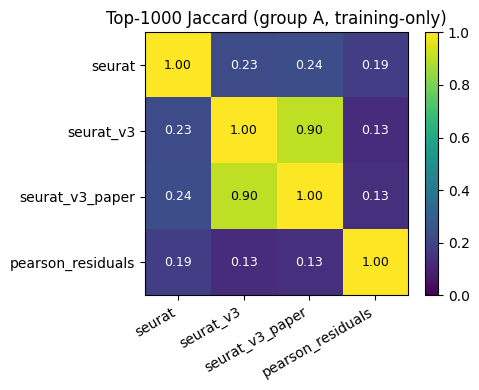

In [8]:
n = len(successful_flavors)
jaccard = pd.DataFrame(np.zeros((n, n)), index=successful_flavors, columns=successful_flavors)
intersection = pd.DataFrame(np.zeros((n, n), dtype=int), index=successful_flavors, columns=successful_flavors)

topsets = {f: set(hvg_results[f].index[hvg_results[f]["highly_variable"]]) for f in successful_flavors}

for fa in successful_flavors:
    for fb in successful_flavors:
        a, b = topsets[fa], topsets[fb]
        union = len(a | b)
        jaccard.loc[fa, fb] = (len(a & b) / union) if union else 0.0
        intersection.loc[fa, fb] = len(a & b)

print("Pairwise Jaccard of top-1000 HVG sets:")
print(jaccard.round(3))
print("\nPairwise intersection size of top-1000 HVG sets:")
print(intersection)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(jaccard.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(successful_flavors, rotation=30, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(successful_flavors)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{jaccard.values[i,j]:.2f}", ha="center", va="center",
                color="white" if jaccard.values[i,j] < 0.5 else "black", fontsize=9)
ax.set_title(f"Top-{N_HVG} Jaccard (group {HOLDOUT_GROUP}, training-only)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 8. Marker panel rank under each flavor

The acid test: where does PTPRC (and other broadly expressed lineage markers) rank under each flavor? Lower rank number = more variable. A flavor that puts PTPRC and the CD3 family at rank ≤ 1000 is rescuing exactly the genes we lost in `01.1`.

In [9]:
rows = []
for label, ensg in MARKER_PANEL.items():
    row = {"marker": label, "ensg": ensg}
    found_in_data = ensg in train_data.var_names
    row["in_data"] = found_in_data
    for f in successful_flavors:
        df = hvg_results[f]
        if found_in_data and ensg in df.index:
            r = df.loc[ensg, "rank"]
            row[f"{f}_rank"]   = int(r) if pd.notna(r) else None
            row[f"{f}_is_hv"]  = bool(df.loc[ensg, "highly_variable"])
        else:
            row[f"{f}_rank"]   = None
            row[f"{f}_is_hv"]  = False
    rows.append(row)

marker_table = pd.DataFrame(rows).set_index("marker")
print(f"Markers found in data: {marker_table['in_data'].sum()} / {len(marker_table)}")
print()
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(marker_table.drop(columns=["ensg", "in_data"]))

n_top = N_HVG
summary = pd.Series({
    f: int(sum(
        (marker_table[f"{f}_rank"].dropna() <= n_top).astype(int)
    ))
    for f in successful_flavors
}, name=f"markers_in_top_{n_top}")
print("\nNumber of marker-panel genes that land in top-1000 per flavor:")
print(summary)

Markers found in data: 16 / 17

               seurat_rank  seurat_is_hv  seurat_v3_rank  seurat_v3_is_hv  seurat_v3_paper_rank  seurat_v3_paper_is_hv  pearson_residuals_rank  pearson_residuals_is_hv
marker                                                                                                                                                                 
PTPRC (CD45)        5323.0         False          6023.0            False                6023.0                  False                   108.0                     True
CD3D                 650.0          True           460.0             True                 460.0                   True                   131.0                     True
CD3E                 139.0          True         12954.0            False               12954.0                  False                   257.0                     True
CD3G                 384.0          True            85.0             True                  85.0                   True          

## 9. Mean expression and detection rate of selected genes

If a flavor is biased toward sparse-but-bright genes, the top-1000's distribution of mean expression will be skewed low and detection rate (fraction of cells with non-zero expression) will be skewed low. PTPRC-style broad markers have moderate-to-high mean and high detection. Comparing the distributions across flavors quantifies the bias we're trying to escape.

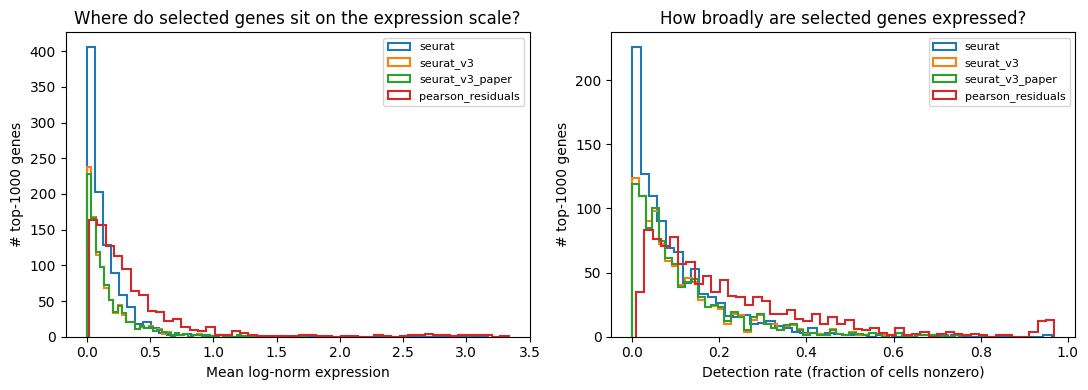

In [10]:
X_log = train_data.X
X_cnt = train_data.layers["counts"]

if sp_sparse.issparse(X_log):
    gene_mean_log    = np.asarray(X_log.mean(axis=0)).ravel()
    gene_detected    = np.asarray((X_cnt > 0).sum(axis=0)).ravel() / X_cnt.shape[0]
else:
    gene_mean_log    = X_log.mean(axis=0)
    gene_detected    = (X_cnt > 0).mean(axis=0)

gene_summary = pd.DataFrame({
    "mean_lognorm": gene_mean_log,
    "detection":    gene_detected,
}, index=train_data.var_names)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for f in successful_flavors:
    sel = hvg_results[f]["highly_variable"]
    g_idx = hvg_results[f].index[sel]
    axes[0].hist(gene_summary.loc[g_idx, "mean_lognorm"], bins=50, histtype="step", label=f, linewidth=1.5)
    axes[1].hist(gene_summary.loc[g_idx, "detection"],    bins=50, histtype="step", label=f, linewidth=1.5)
axes[0].set_xlabel("Mean log-norm expression"); axes[0].set_ylabel("# top-1000 genes")
axes[0].set_title("Where do selected genes sit on the expression scale?")
axes[1].set_xlabel("Detection rate (fraction of cells nonzero)"); axes[1].set_ylabel("# top-1000 genes")
axes[1].set_title("How broadly are selected genes expressed?")
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Save HVG lists and a summary so `01.3` (or `01.5`) can read it

Writes one CSV per flavor (full per-gene rank table) plus a small `summary.json` recording the chosen group, marker recovery, and pairwise Jaccard. Once we settle on a flavor we update `01.3`'s `sc.pp.highly_variable_genes` call accordingly.

In [11]:
for f in successful_flavors:
    out_csv = os.path.join(OUT_DIR, f"hvg_{HOLDOUT_GROUP}_{f}.csv")
    hvg_results[f].to_csv(out_csv)
    print(f"  wrote {out_csv}  ({len(hvg_results[f])} rows)")

marker_table.to_csv(os.path.join(OUT_DIR, f"marker_rank_{HOLDOUT_GROUP}.csv"))
jaccard.to_csv(os.path.join(OUT_DIR, f"jaccard_{HOLDOUT_GROUP}.csv"))

summary_obj = {
    "holdout_group":   HOLDOUT_GROUP,
    "holdout_ids":     GROUPS[HOLDOUT_GROUP]["holdout_ids"],
    "n_top_genes":     N_HVG,
    "n_train_cells":   int(train_data.n_obs),
    "n_holdout_cells": int(holdout_data.n_obs),
    "n_genes":         int(train_data.n_vars),
    "flavors":         successful_flavors,
    "markers_in_top":  summary.to_dict(),
    "pairwise_jaccard": jaccard.round(4).to_dict(),
}
with open(os.path.join(OUT_DIR, f"summary_{HOLDOUT_GROUP}.json"), "w") as fp:
    json.dump(summary_obj, fp, indent=2)

print("\nSummary:")
print(json.dumps(summary_obj, indent=2))

  wrote /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_outputs/hvg_A_seurat.csv  (14451 rows)
  wrote /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_outputs/hvg_A_seurat_v3.csv  (14451 rows)
  wrote /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_outputs/hvg_A_seurat_v3_paper.csv  (14451 rows)
  wrote /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_outputs/hvg_A_pearson_residuals.csv  (14451 rows)

Summary:
{
  "holdout_group": "A",
  "holdout_ids": [
    "CL:0000625"
  ],
  "n_top_genes": 1000,
  "n_train_cells": 12600,
  "n_holdout_cells": 390,
  "n_genes": 14451,
  "flavors": [
    "seurat",
    "seurat_v3",
    "seurat_v3_paper",
    "pearson_residuals"
  ],
  "markers_in_top": {
    "seurat": 10,
    "seurat_v3": 11,
    "seurat_v3_paper": 11,
    "pearson_residuals": 8
  },
  "pairwise_jaccard": {
    "seurat": {
      "seurat":

## Next steps

1. Pick the winning flavor based on (a) marker recovery and (b) breadth of detected expression in section 9.
2. Update `01.3`'s `sc.pp.highly_variable_genes(...)` call to use that flavor (and the appropriate input layer if it expects raw counts), and **also move the HVG step to AFTER the per-group holdout split** so each group has its own training-only HVG list.
3. Re-run downstream models (CellOT, IMPACT-OR, scGen) on the regenerated holdout files.
4. Compare against the current renorm baseline in `08.2` (renorm-with-leakage vs renorm-training-only) to quantify how much of the previous accuracy was leakage.